# Demo — 1 Commit

Heterogeneous graph for a **single** TensorFlow VCC commit.

Commit: `7b8db6083b34` — ezhulenev, 2021-03-19, `conv_ops.cc`, CVE-2021-41206

Uses `build_graph()` directly. Shows all intra-commit node and edge types:
`commit → file → function`, `commit → developer`, `commit → issue/PR/release_tag`.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import torch
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from graph_builder import build_graph, build_multi_commit_graph, load_all_tables, get_repo_commits

/Users/tolgakuntman/miniconda3/envs/thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print('Loading tables ...')
tables = load_all_tables('..')
for k, v in tables.items():
    print(f'  {k:25s}: {v.shape if v is not None else "None"}')

Loading tables ...
  commit_info              : (8796, 21)
  file_info                : (10872, 16)
  function_info            : (12847, 15)
  ownership_window         : (269831, 16)
  developer_info           : (38007, 9)
  commit_author            : (11360, 3)
  commit_features          : (8773, 16)
  issue_info               : (691670, 10)
  pr_info                  : (469952, 13)
  release_tag_info         : (6617, 8)
  vcc_fc_mapping           : (9947, 5)


In [3]:
COMMIT_HASH = '7b8db6083b34520688dbc71f341f7aeaf156bf17'  # VCC  ezhulenev  conv_ops.cc  CVE-2021-41206

MODE                = 4
OWNERSHIP_THRESHOLD = 0.05
OWNERSHIP_WINDOW    = 90
MAX_ISSUES          = 20
MAX_PRS             = 20

print(f'Building single-commit graph: {COMMIT_HASH[:12]} ...')
g = build_graph(
    COMMIT_HASH, tables,
    mode                  = MODE,
    ownership_window_days = OWNERSHIP_WINDOW,
    ownership_threshold   = OWNERSHIP_THRESHOLD,
    max_issues            = MAX_ISSUES,
    max_prs               = MAX_PRS,
)
print(g)

Building single-commit graph: 7b8db6083b34 ...
HeteroData(
  commit={ x=[1, 9] },
  file={ x=[1, 10] },
  function={ x=[1, 5] },
  developer={ x=[4, 4] },
  issue={ x=[1, 2] },
  pull_request={ x=[1, 2] },
  release_tag={ x=[1, 2] },
  (commit, has, file)={
    edge_index=[2, 1],
    edge_attr=[1, 10],
  },
  (file, has, function)={
    edge_index=[2, 1],
    edge_attr=[1, 6],
  },
  (function, co_modified, function)={
    edge_index=[2, 0],
    edge_attr=[0, 2],
  },
  (commit, authored_by, developer)={
    edge_index=[2, 1],
    edge_attr=[1, 1],
  },
  (commit, committed_by, developer)={
    edge_index=[2, 1],
    edge_attr=[1, 1],
  },
  (developer, owns, file)={
    edge_index=[2, 4],
    edge_attr=[4, 3],
  },
  (commit, linked_issue, issue)={ edge_index=[2, 1] },
  (issue, issue_of, commit)={ edge_index=[2, 1] },
  (commit, linked_pr, pull_request)={ edge_index=[2, 1] },
  (pull_request, pr_of, commit)={ edge_index=[2, 1] },
  (commit, has_release_tag, release_tag)={
    edge_in

In [4]:
print('Node types:')
for nt in g.node_types:
    x = g[nt].x
    print(f'  {nt:15s}: {x.shape[0]:4d} nodes  feat_dim={x.shape[1]}')
print('\nEdge types:')
for et in g.edge_types:
    ei = g[et].edge_index
    ea = g[et].get('edge_attr')
    attr = f'  attr={ea.shape[1]}' if ea is not None else ''
    print(f'  {str(et):55s}: {ei.shape[1]:4d} edges{attr}')

Node types:
  commit         :    1 nodes  feat_dim=9
  file           :    1 nodes  feat_dim=10
  function       :    1 nodes  feat_dim=5
  developer      :    4 nodes  feat_dim=4
  issue          :    1 nodes  feat_dim=2
  pull_request   :    1 nodes  feat_dim=2
  release_tag    :    1 nodes  feat_dim=2

Edge types:
  ('commit', 'has', 'file')                              :    1 edges  attr=10
  ('file', 'has', 'function')                            :    1 edges  attr=6
  ('function', 'co_modified', 'function')                :    0 edges  attr=2
  ('commit', 'authored_by', 'developer')                 :    1 edges  attr=1
  ('commit', 'committed_by', 'developer')                :    1 edges  attr=1
  ('developer', 'owns', 'file')                          :    4 edges  attr=3
  ('commit', 'linked_issue', 'issue')                    :    1 edges
  ('issue', 'issue_of', 'commit')                        :    1 edges
  ('commit', 'linked_pr', 'pull_request')                :    1 edges
 

Saved to outputs/demo_1_commit.png


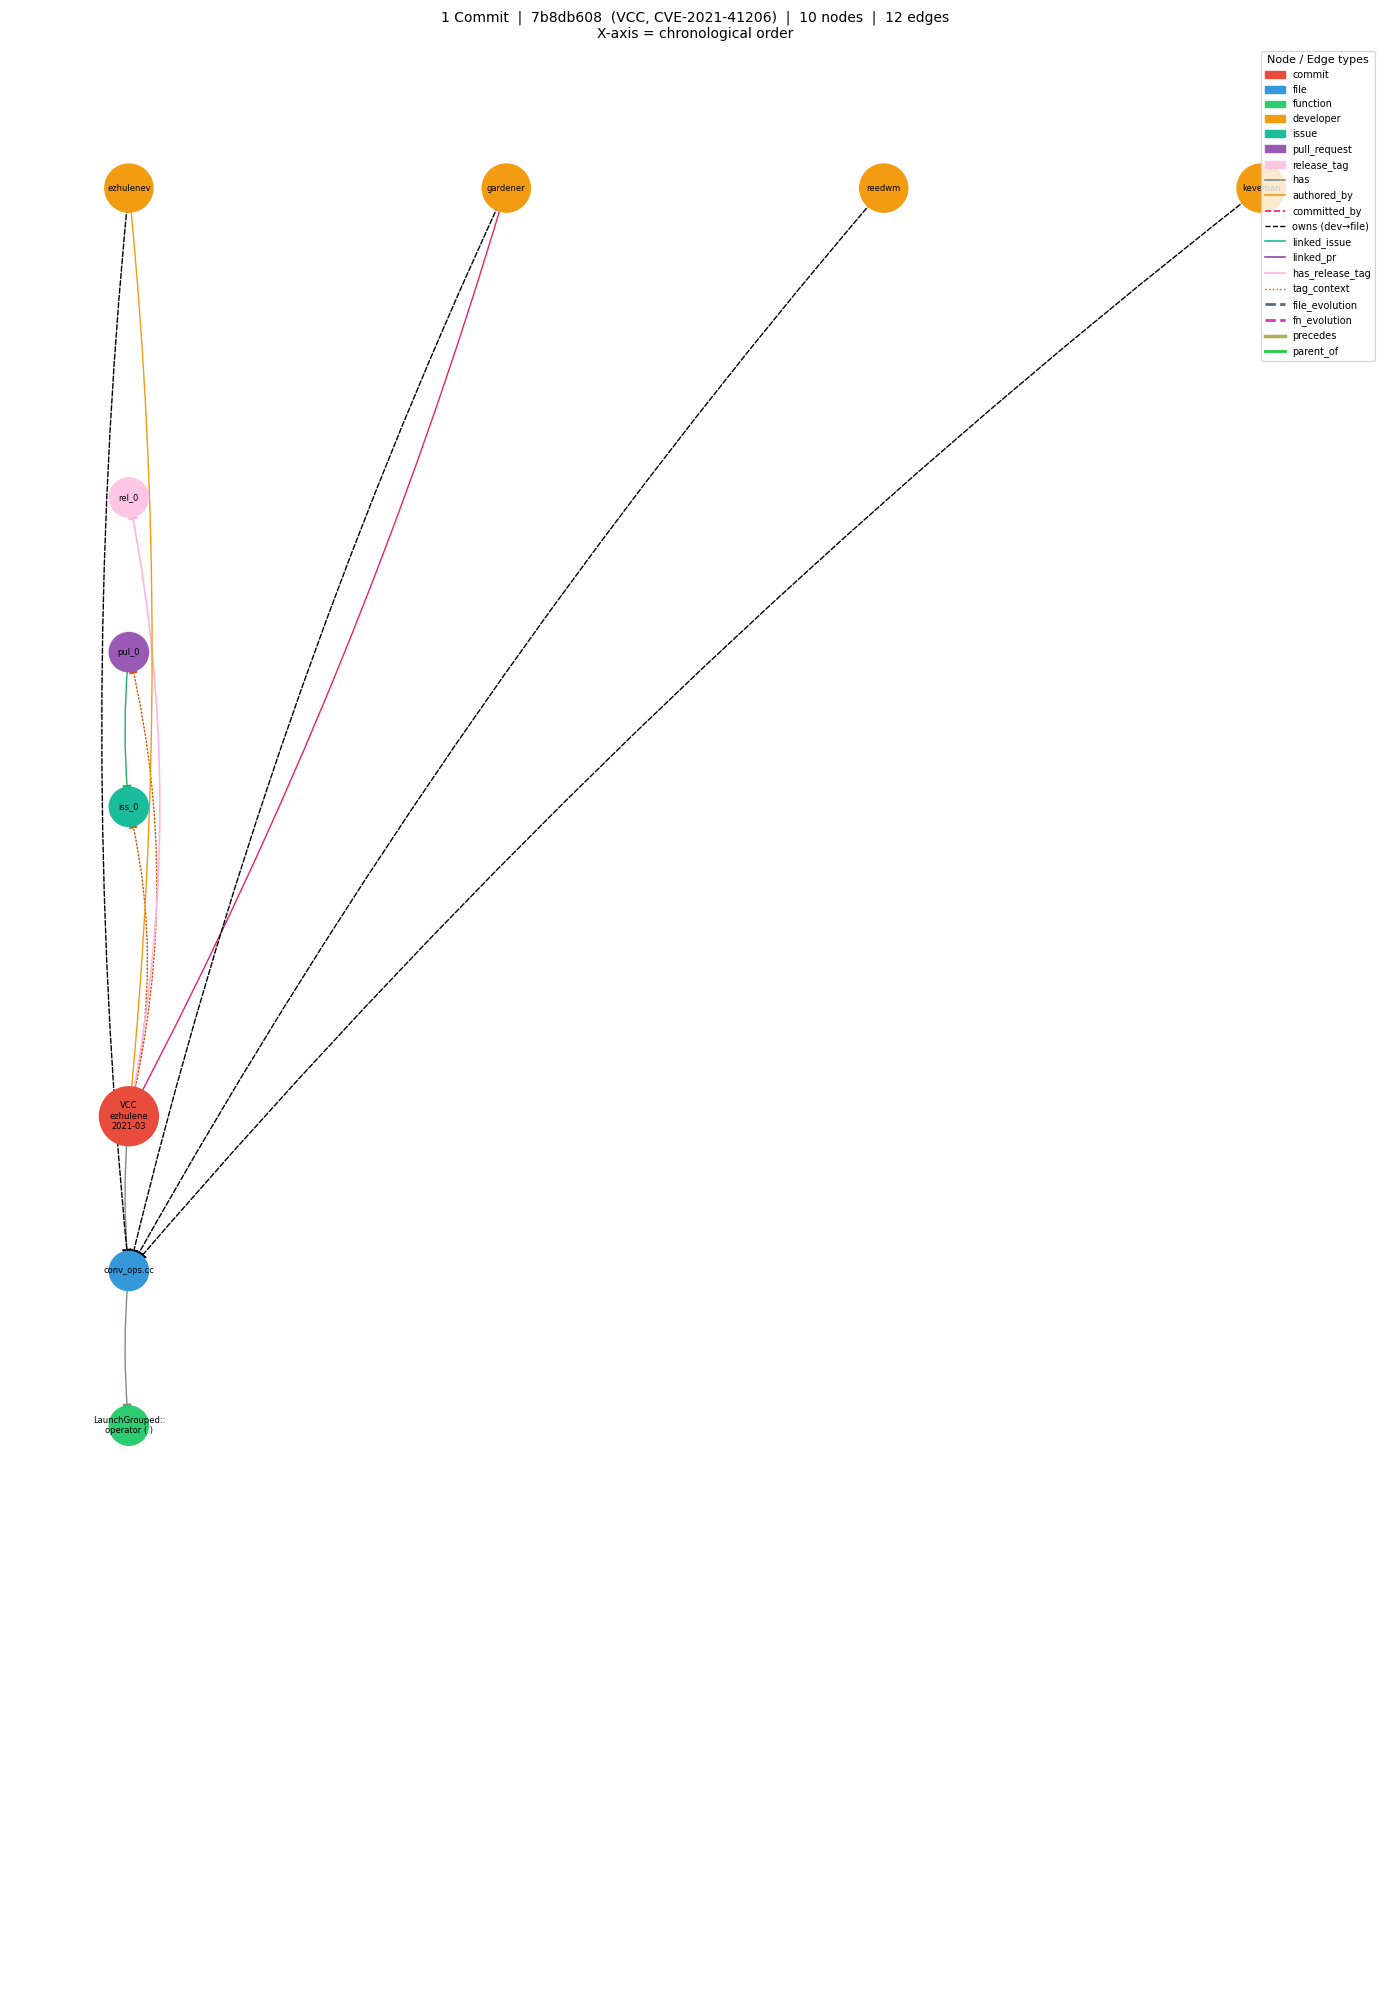

In [5]:
COLOUR = {
    'commit':       '#e74c3c',
    'file':         '#3498db',
    'function':     '#2ecc71',
    'developer':    '#f39c12',
    'issue':        '#1abc9c',
    'pull_request': '#9b59b6',
    'release_tag':  '#fec5e5',
}
EDGE_COLOUR = {
    'has':               '#7f8c8d',
    'authored_by':       '#f39c12',
    'committed_by':      '#e6226d',
    'owns':              '#000000',
    'co_modified':       '#9de89f',
    'linked_issue':      '#1abc9c',
    'linked_pr':         '#8e44ad',
    'has_release_tag':   '#ffb5e4',
    'tag_context_pr':    '#d35400',
    'tag_context_issue': '#d35400',
    'references_issue':  '#27ae60',
    'file_evolution':    '#516a83',
    'fn_evolution':      '#d03ab9',
    'parent_of':         '#1bd245',
    'precedes':          '#aab258',
}

def visualise(mg, commit_hashes, tables, title, outfile=None,
              mode=4, ownership_window=90, ownership_threshold=0.05,
              max_issues=20, max_prs=20):
    ci = tables['commit_info']
    commit_dates = {}
    for h in commit_hashes:
        row = ci[ci['hash'] == h]
        if not row.empty:
            commit_dates[h] = pd.to_datetime(row['author_date'].values[0], utc=True)

    sorted_commits = sorted(enumerate(commit_hashes),
                            key=lambda x: commit_dates.get(x[1], pd.Timestamp('2000', tz='UTC')))
    commit_x = {idx: rank for rank, (idx, _) in enumerate(sorted_commits)}
    TYPE_Y = {'commit': 0, 'file': -1.5, 'function': -3.0,
              'developer': 1.5, 'issue': 3.0, 'pull_request': 4.5, 'release_tag': 6.0}

    node_pos, node_type, node_label = {}, {}, {}
    SNAP = ['commit', 'file', 'function', 'issue', 'pull_request', 'release_tag']
    offsets_vis = {nt: [0] for nt in SNAP}
    for h in commit_hashes:
        try:
            sg = build_graph(h, tables, mode=mode,
                             ownership_window_days=ownership_window,
                             ownership_threshold=ownership_threshold,
                             max_issues=max_issues, max_prs=max_prs)
            for nt in SNAP:
                n = sg[nt].x.shape[0] if nt in sg.node_types else 0
                offsets_vis[nt].append(offsets_vis[nt][-1] + n)
        except Exception:
            for nt in SNAP:
                offsets_vis[nt].append(offsets_vis[nt][-1])

    for i, h in enumerate(commit_hashes):
        cx = commit_x[i] * 3.5
        row = ci[ci['hash'] == h]
        ctype  = row['commit_type'].values[0] if len(row) else '?'
        author = row['author'].values[0].split('@')[0] if len(row) else '?'
        date   = commit_dates.get(h)
        date_s = date.strftime('%Y-%m') if date else '?'
        for nt in SNAP:
            for j, gidx in enumerate(range(offsets_vis[nt][i], offsets_vis[nt][i+1])):
                nid = f'{nt}_{gidx}'
                node_pos[nid]  = (cx, TYPE_Y[nt] + j * 0.6)
                node_type[nid] = nt
                if nt == 'commit':
                    node_label[nid] = f'{ctype}\n{author[:8]}\n{date_s}'
                elif nt == 'file':
                    frow = tables['file_info'][tables['file_info']['hash']==h].reset_index(drop=True)
                    node_label[nid] = frow.iloc[j]['filename'] if j < len(frow) else f'f{j}'
                elif nt == 'function':
                    fnrow = tables['function_info'][tables['function_info']['hash']==h].reset_index(drop=True)
                    fn_name = fnrow.iloc[j]['name'] if j < len(fnrow) else f'fn{j}'
                    fn_clean = str(fn_name)
                    for pfx in ('tensorflow::', 'tflite::'):
                        fn_clean = fn_clean.replace(pfx, '')
                    if '::' in fn_clean:
                        cls, _, meth = fn_clean.rpartition('::')
                        node_label[nid] = f'{cls[:20]}::\n{meth[:14]}'
                    else:
                        node_label[nid] = fn_clean[:22]
                else:
                    node_label[nid] = f'{nt[:3]}_{gidx}'

    n_devs = mg['developer'].x.shape[0]
    dev_map = mg['developer']._email_to_idx if hasattr(mg['developer'], '_email_to_idx') else {}
    idx_to_email = {v: k for k, v in dev_map.items()}
    for didx in range(n_devs):
        nid = f'developer_{didx}'
        node_pos[nid]  = (didx * 3.0, 9.0)
        node_type[nid] = 'developer'
        node_label[nid] = idx_to_email.get(didx, f'dev{didx}').split('@')[0][:10]

    REVERSE = {'issue_of','pr_of','tag_of','referenced_by_pr','prev_tag',
               'prev_issue','prev_pr','tag_context_of','in_release'}
    SKIP    = {'next_issue','next_pr','affects_pr','affects_issue'}
    G = nx.DiGraph()
    for nid, pos in node_pos.items():
        G.add_node(nid, pos=pos, ntype=node_type[nid])
    for et in mg.edge_types:
        src_t, rel, dst_t = et
        if rel in REVERSE or rel in SKIP: continue
        ei = mg[et].edge_index
        for k in range(ei.shape[1]):
            s, d = f'{src_t}_{ei[0,k].item()}', f'{dst_t}_{ei[1,k].item()}'
            if s in node_pos and d in node_pos:
                G.add_edge(s, d, rel=rel)

    pos_dict    = {n: d['pos'] for n, d in G.nodes(data=True)}
    node_colors = [COLOUR.get(G.nodes[n]['ntype'], '#bdc3c7') for n in G.nodes]
    node_sizes  = [1800 if G.nodes[n]['ntype']=='commit' else
                   1200 if G.nodes[n]['ntype']=='developer' else 800 for n in G.nodes]

    STYLE = {
        'file_evolution':    dict(width=2.0, style='dashed', rad=0.20),
        'fn_evolution':      dict(width=2.0, style='dashed', rad=0.15),
        'precedes':          dict(width=2.5, style='solid',  rad=0.25),
        'parent_of':         dict(width=2.0, style='solid',  rad=0.20),
        'owns':              dict(width=1.0, style='dashed', rad=0.05),
        'has_release_tag':   dict(width=1.2, style='solid',  rad=0.10),
        'linked_issue':      dict(width=1.2, style='solid',  rad=0.10),
        'linked_pr':         dict(width=1.2, style='solid',  rad=0.10),
        'tag_context_pr':    dict(width=1.0, style='dotted', rad=0.12),
        'tag_context_issue': dict(width=1.0, style='dotted', rad=0.12),
        'next_tag':          dict(width=1.0, style='solid',  rad=0.08),
    }

    n_commits = len(commit_hashes)
    fig, ax = plt.subplots(figsize=(max(14, n_commits * 3.5), 20))
    edge_groups = {}
    for u, v, d in G.edges(data=True):
        edge_groups.setdefault(d['rel'], []).append((u, v))
    for rel, edges in edge_groups.items():
        col = EDGE_COLOUR.get(rel, '#95a5a6')
        s   = STYLE.get(rel, dict(width=1.0, style='solid', rad=0.05))
        nx.draw_networkx_edges(G, pos_dict, edgelist=edges, edge_color=col,
                               style=s['style'], arrows=True, arrowsize=14,
                               width=s['width'], connectionstyle=f'arc3,rad={s["rad"]}', ax=ax)
    nx.draw_networkx_nodes(G, pos_dict, node_color=node_colors, node_size=node_sizes, ax=ax)
    nx.draw_networkx_labels(G, pos_dict, labels={n: node_label.get(n, n) for n in G.nodes},
                            font_size=6, ax=ax)

    node_leg = [mpatches.Patch(color=c, label=nt) for nt, c in COLOUR.items()]
    edge_leg  = [
        Line2D([0],[0], color=EDGE_COLOUR['has'],               lw=1.2,          label='has'),
        Line2D([0],[0], color=EDGE_COLOUR['authored_by'],       lw=1.2,          label='authored_by'),
        Line2D([0],[0], color=EDGE_COLOUR['committed_by'],      lw=1.2, ls='--', label='committed_by'),
        Line2D([0],[0], color=EDGE_COLOUR['owns'],              lw=1.0, ls='--', label='owns (dev→file)'),
        Line2D([0],[0], color=EDGE_COLOUR['linked_issue'],      lw=1.2,          label='linked_issue'),
        Line2D([0],[0], color=EDGE_COLOUR['linked_pr'],         lw=1.2,          label='linked_pr'),
        Line2D([0],[0], color=EDGE_COLOUR['has_release_tag'],   lw=1.2,          label='has_release_tag'),
        Line2D([0],[0], color=EDGE_COLOUR['tag_context_issue'], lw=1.0, ls=':',  label='tag_context'),
        Line2D([0],[0], color=EDGE_COLOUR['file_evolution'],    lw=2.0, ls='--', label='file_evolution'),
        Line2D([0],[0], color=EDGE_COLOUR['fn_evolution'],      lw=2.0, ls='--', label='fn_evolution'),
        Line2D([0],[0], color=EDGE_COLOUR['precedes'],          lw=2.5,          label='precedes'),
        Line2D([0],[0], color=EDGE_COLOUR['parent_of'],         lw=2.0,          label='parent_of'),
    ]
    ax.legend(handles=node_leg + edge_leg, loc='upper right', fontsize=7,
              title='Node / Edge types', title_fontsize=8)
    ax.set_title(f'{title}  |  {G.number_of_nodes()} nodes  |  {G.number_of_edges()} edges'
                 f'\nX-axis = chronological order', fontsize=10)
    ax.axis('off')
    plt.tight_layout()
    if outfile:
        import os
        os.makedirs('../outputs', exist_ok=True)
        plt.savefig(f'../outputs/{outfile}', dpi=150, bbox_inches='tight')
        print(f'Saved to outputs/{outfile}')
    plt.show()

# Wrap in multi-commit builder so the shared visualiser works
mg = build_multi_commit_graph(
    [COMMIT_HASH], tables,
    mode=MODE,
    ownership_threshold=OWNERSHIP_THRESHOLD,
    ownership_window_days=OWNERSHIP_WINDOW,
    max_issues=MAX_ISSUES, max_prs=MAX_PRS,
)
visualise(mg, [COMMIT_HASH], tables,
          title='1 Commit  |  7b8db608  (VCC, CVE-2021-41206)',
          outfile='demo_1_commit.png')